Saving smartphones ranked.xlsx to smartphones ranked.xlsx
Dataset Shape: (99, 9)


,Brand,Price_Range,Battery_mAh,Camera_MP,Storage_GB,5G_Support,Charging_Type,Warranty,Rank
0,Xiaomi,Medium,4000,48,128,Yes,Fast,Yes,63
1,Google,Low,5500,64,256,Yes,Fast,No,41
2,OnePlus,Medium,5500,108,128,Yes,Fast,Yes,96
3,Google,Low,4500,108,512,Yes,SuperFast,Yes,19
4,Google,High,5500,108,512,Yes,Normal,Yes,98


                            OLS Regression Results                            
Dep. Variable:             Preference   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.346
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.203
Time:                        04:50:10   Log-Likelihood:                -463.12
No. Observations:                  99   AIC:                             954.2
Df Residuals:                      85   BIC:                             990.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

,Attribute_Level,Utility
8,Price_Range_Medium,11.717458
11,Charging_Type_SuperFast,11.199924
10,Charging_Type_Normal,7.934578
7,Price_Range_Low,6.565214
3,Brand_Google,4.201828
9,5G_Support_Yes,2.725241
2,Storage_GB,0.017828
0,Battery_mAh,-0.006717
1,Camera_MP,-0.206303
12,Warranty_Yes,-4.427746


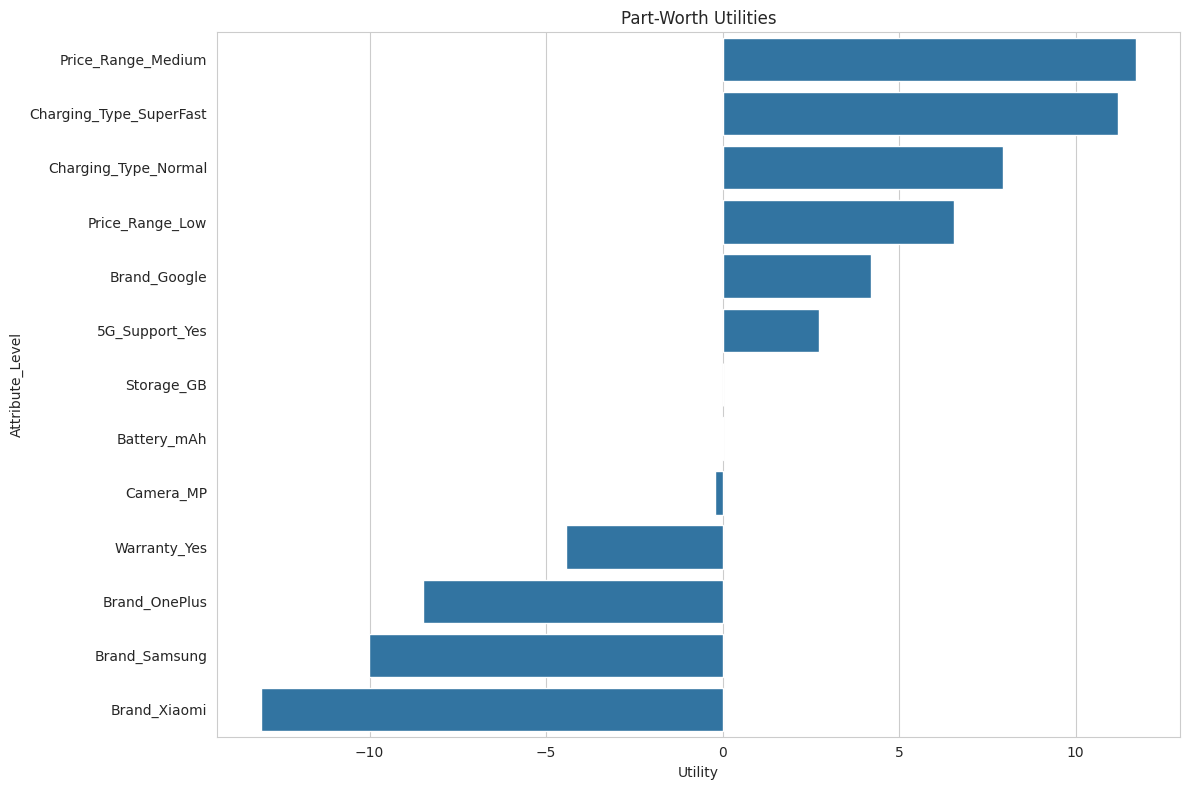


Attribute Importance


,Attribute,Range,Importance_%
0,Brand,17.280888,67.244790
1,Price_Range,5.152245,20.048832
3,Charging_Type,3.265346,12.706379
2,5G_Support,0.000000,0.000000
4,Warranty,0.000000,0.000000


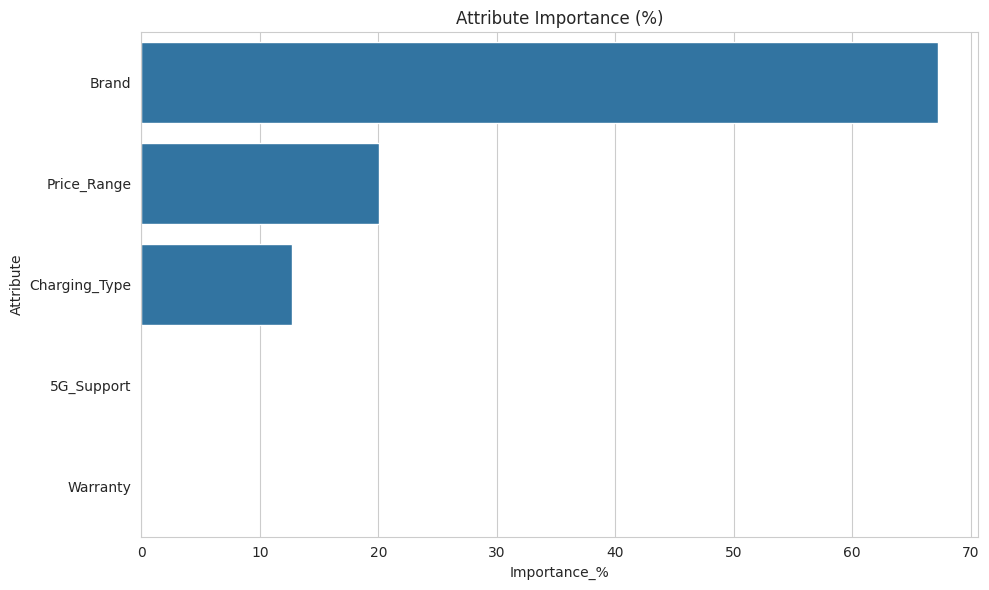

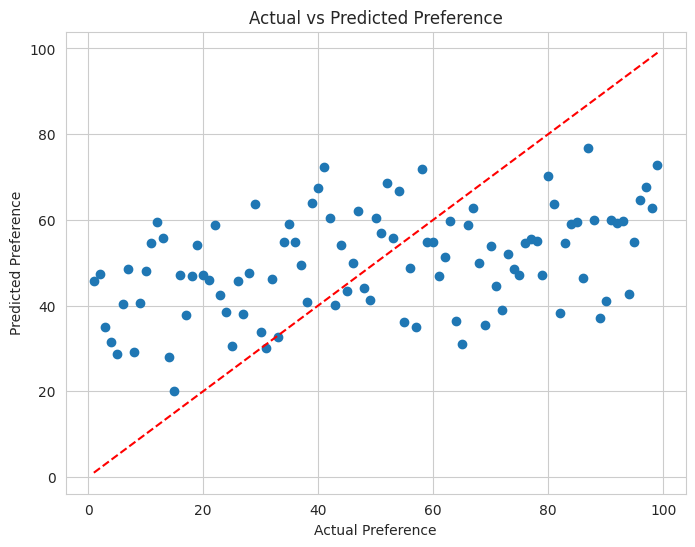


Best Attribute Levels
{'Brand': 'Brand_Google', 'Price_Range': 'Price_Range_Medium', '5G_Support': '5G_Support_Yes', 'Charging_Type': 'Charging_Type_SuperFast', 'Warranty': 'Warranty_Yes'}
Files Exported Successfully


In [1]:
# ==========================================
# CONJOINT ANALYSIS - SMARTPHONE DATASET
# ==========================================

!pip install pandas numpy openpyxl statsmodels seaborn matplotlib scikit-learn -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# UPLOAD FILE
# ==========================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Dataset Shape:", df.shape)
display(df.head())

# ==========================================
# CREATE PREFERENCE SCORE
# ==========================================

# Lower rank = better preference
# Convert rank into preference score

df['Preference'] = df['Rank'].max() + 1 - df['Rank']

# ==========================================
# CONJOINT ATTRIBUTES
# ==========================================

attributes = [
    'Brand',
    'Price_Range',
    'Battery_mAh',
    'Camera_MP',
    'Storage_GB',
    '5G_Support',
    'Charging_Type',
    'Warranty'
]

target = 'Preference'

# ==========================================
# ONE HOT ENCODING
# ==========================================

X = pd.get_dummies(
    df[attributes],
    drop_first=True,
    dtype=float
)

y = df[target]

X = sm.add_constant(X)

# ==========================================
# FIT CONJOINT MODEL
# ==========================================

model = sm.OLS(y, X).fit()

print(model.summary())

# ==========================================
# PART-WORTH UTILITIES
# ==========================================

utilities = model.params.drop('const')

utility_df = pd.DataFrame({
    'Attribute_Level': utilities.index,
    'Utility': utilities.values
})

utility_df = utility_df.sort_values(
    by='Utility',
    ascending=False
)

print("\nPart Worth Utilities")
display(utility_df)

# ==========================================
# VISUALIZATION 1
# PART-WORTH UTILITIES
# ==========================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=utility_df,
    x='Utility',
    y='Attribute_Level'
)

plt.title('Part-Worth Utilities')
plt.tight_layout()
plt.show()

# ==========================================
# ATTRIBUTE IMPORTANCE
# ==========================================

importance = {}

for attr in attributes:

    cols = [
        col for col in utility_df['Attribute_Level']
        if col.startswith(attr + "_")
    ]

    if len(cols) > 0:

        vals = utility_df[
            utility_df['Attribute_Level'].isin(cols)
        ]['Utility']

        importance[attr] = vals.max() - vals.min()

importance_df = pd.DataFrame({
    'Attribute': importance.keys(),
    'Range': importance.values()
})

importance_df['Importance_%'] = (
    importance_df['Range']
    / importance_df['Range'].sum()
) * 100

importance_df = importance_df.sort_values(
    by='Importance_%',
    ascending=False
)

print("\nAttribute Importance")
display(importance_df)

# ==========================================
# VISUALIZATION 2
# ATTRIBUTE IMPORTANCE
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance_%',
    y='Attribute'
)

plt.title('Attribute Importance (%)')
plt.tight_layout()
plt.show()

# ==========================================
# PREDICTED PREFERENCES
# ==========================================

df['Predicted_Preference'] = model.predict(X)

# ==========================================
# VISUALIZATION 3
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    df['Preference'],
    df['Predicted_Preference']
)

plt.xlabel('Actual Preference')
plt.ylabel('Predicted Preference')
plt.title('Actual vs Predicted Preference')

plt.plot(
    [df['Preference'].min(),
     df['Preference'].max()],
    [df['Preference'].min(),
     df['Preference'].max()],
    'r--'
)

plt.show()

# ==========================================
# TOP SMARTPHONE CONFIGURATION
# ==========================================

best_levels = {}

for attr in attributes:

    cols = utility_df[
        utility_df['Attribute_Level'].str.startswith(attr + "_")
    ]

    if len(cols) > 0:

        best = cols.iloc[0]

        best_levels[attr] = best['Attribute_Level']

print("\nBest Attribute Levels")
print(best_levels)

# ==========================================
# EXPORT RESULTS
# ==========================================

utility_df.to_excel(
    "Part_Worth_Utilities.xlsx",
    index=False
)

importance_df.to_excel(
    "Attribute_Importance.xlsx",
    index=False
)

print("Files Exported Successfully")

Saving smartphones ranked.xlsx to smartphones ranked (1).xlsx
DATASET INFORMATION
Rows: 99
Columns: 9


,Brand,Price_Range,Battery_mAh,Camera_MP,Storage_GB,5G_Support,Charging_Type,Warranty,Rank
0,Xiaomi,Medium,4000,48,128,Yes,Fast,Yes,63
1,Google,Low,5500,64,256,Yes,Fast,No,41
2,OnePlus,Medium,5500,108,128,Yes,Fast,Yes,96
3,Google,Low,4500,108,512,Yes,SuperFast,Yes,19
4,Google,High,5500,108,512,Yes,Normal,Yes,98




CONJOINT MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:             Preference   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.346
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.203
Time:                        04:55:34   Log-Likelihood:                -463.12
No. Observations:                  99   AIC:                             954.2
Df Residuals:                      85   BIC:                             990.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
c

,Attribute_Level,Utility
8,Price_Range_Medium,11.717458
11,Charging_Type_SuperFast,11.199924
10,Charging_Type_Normal,7.934578
7,Price_Range_Low,6.565214
3,Brand_Google,4.201828
9,5G_Support_Yes,2.725241
2,Storage_GB,0.017828
0,Battery_mAh,-0.006717
1,Camera_MP,-0.206303
12,Warranty_Yes,-4.427746


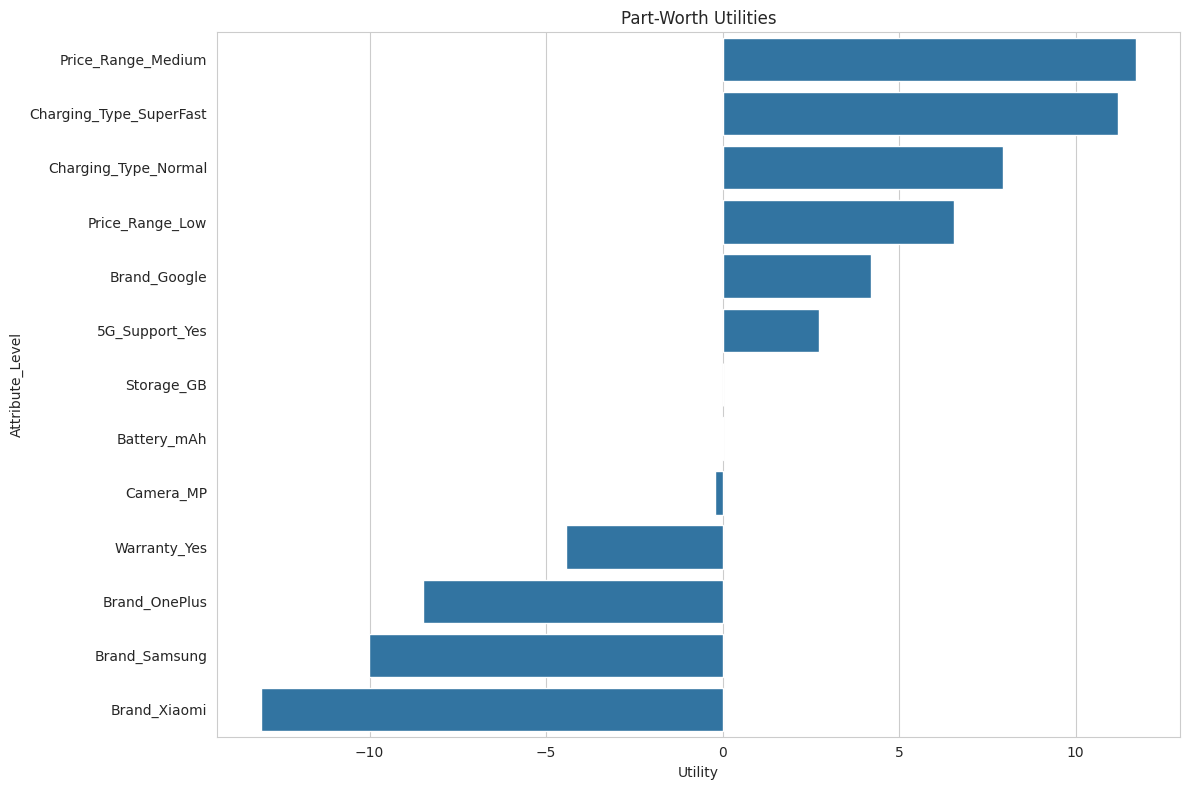


INTERPRETATION
Positive utilities indicate preferred features.
Negative utilities indicate less preferred features.


ATTRIBUTE IMPORTANCE


,Attribute,Range,Importance_%
0,Brand,17.280888,67.244790
1,Price_Range,5.152245,20.048832
3,Charging_Type,3.265346,12.706379
2,5G_Support,0.000000,0.000000
4,Warranty,0.000000,0.000000


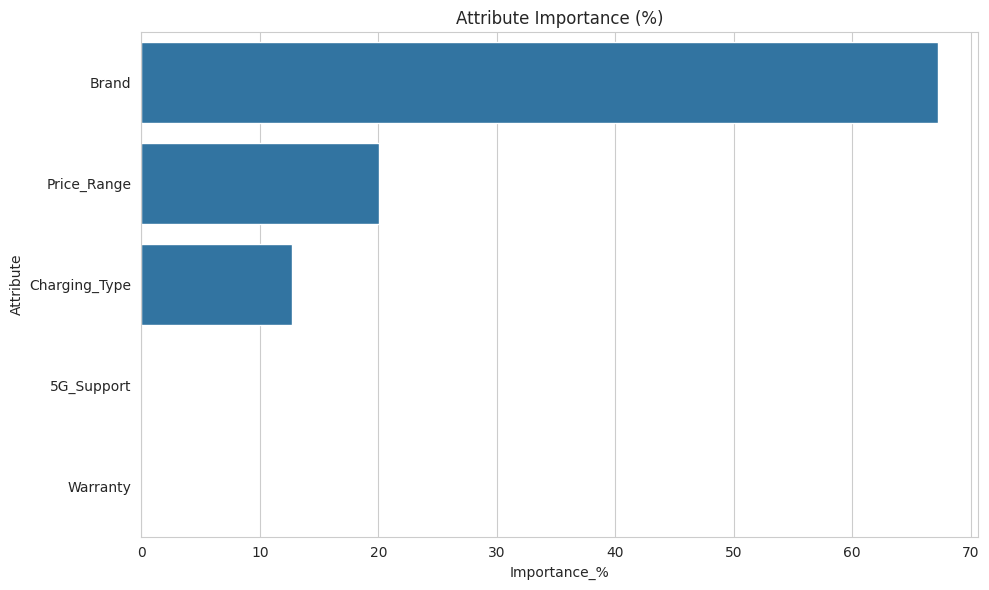


MOST IMPORTANT ATTRIBUTE:
Brand


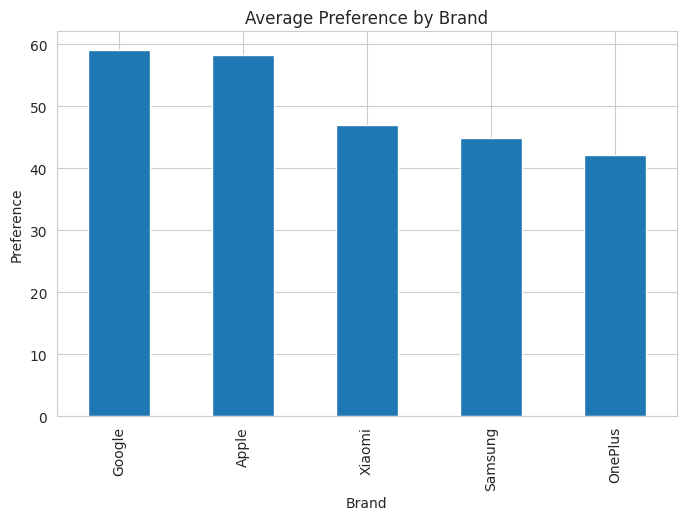


BRAND PREFERENCE
Brand
Google     59.105263
Apple      58.176471
Xiaomi     47.038462
Samsung    44.857143
OnePlus    42.062500
Name: Preference, dtype: float64


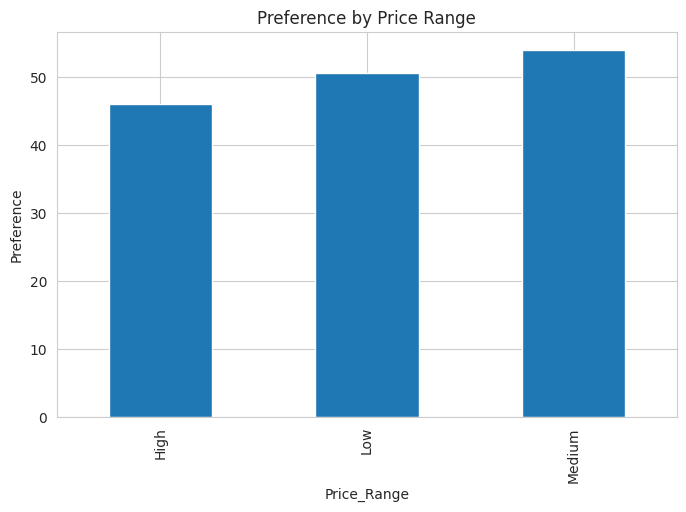


PRICE SENSITIVITY
Price_Range
High      46.058824
Low       50.648649
Medium    53.928571
Name: Preference, dtype: float64


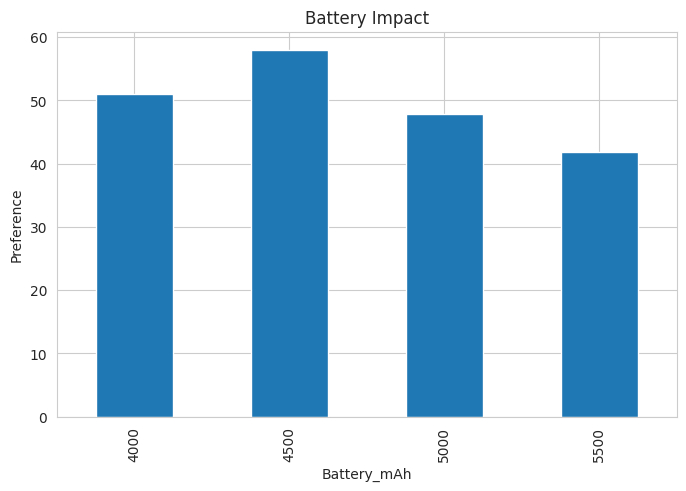

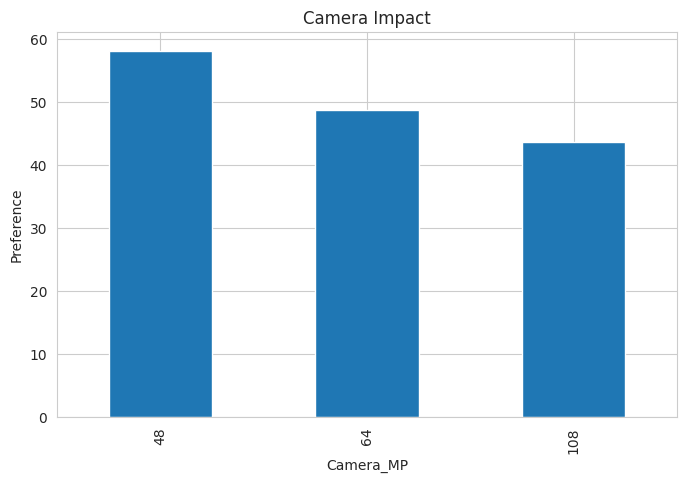

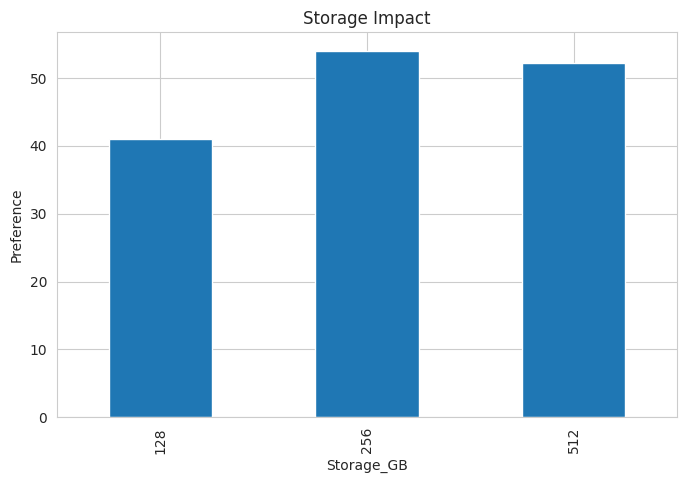

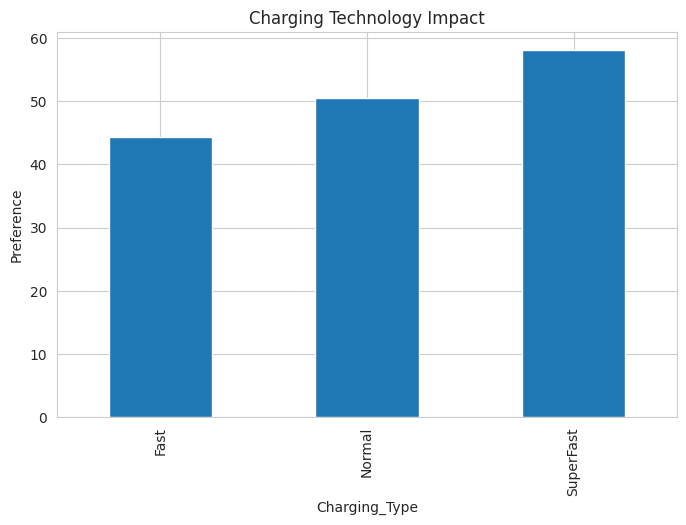

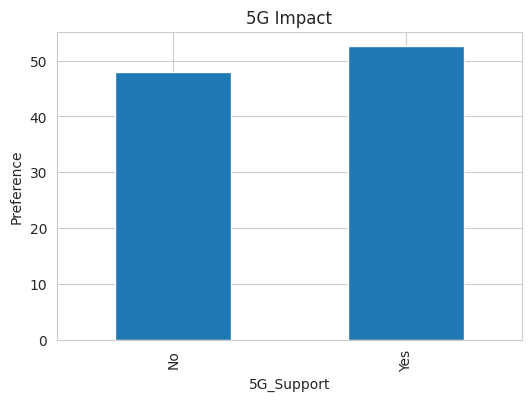

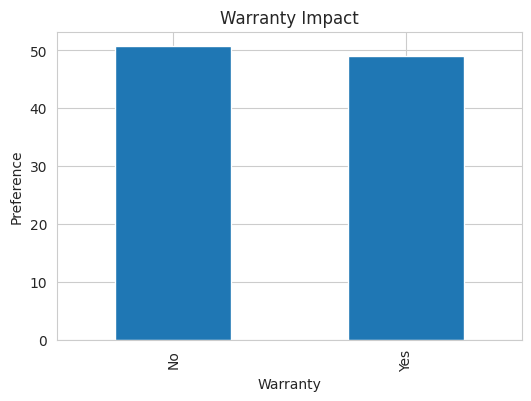

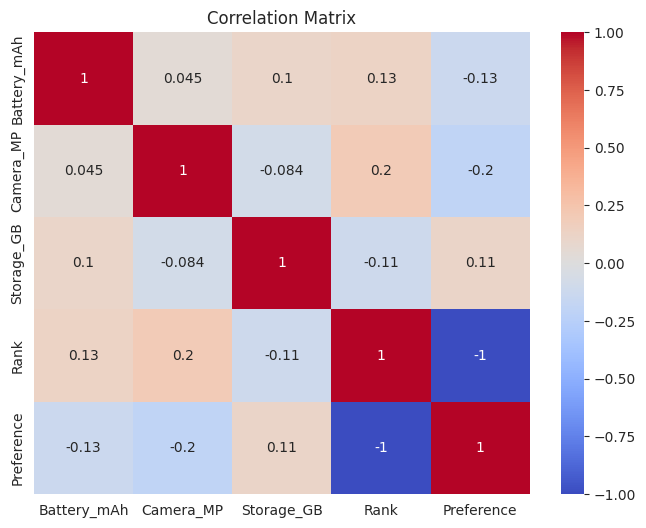



MODEL PERFORMANCE
R² = 0.171
Adjusted R² = 0.044


BEST SMARTPHONE CONFIGURATION
Brand_Google
Price_Range_Medium
5G_Support_Yes
Charging_Type_SuperFast
Warranty_Yes


MANAGERIAL INSIGHTS

1. The most important purchase driver is Brand.

2. Positive utility values indicate features preferred by consumers.

3. Negative utility values indicate features consumers dislike.

4. The attribute importance chart shows which smartphone
   characteristics have the strongest influence on buying decisions.

5. The optimal smartphone configuration consists of the
   highest-utility levels identified above.

6. Managers should focus on attributes with the highest
   importance percentages to maximize customer preference.

7. Features with strong positive utilities should be emphasized
   in product design and marketing campaigns.


Files Exported:
Part_Worth_Utilities.xlsx
Attribute_Importance.xlsx


In [3]:
# ============================================================
# SMARTPHONE CONJOINT ANALYSIS - COMPLETE MBA PROJECT
# ============================================================

!pip install pandas openpyxl statsmodels seaborn matplotlib -q

import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# ============================================================
# UPLOAD FILE
# ============================================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

# ============================================================
# CREATE PREFERENCE SCORE
# ============================================================

df["Preference"] = df["Rank"].max() + 1 - df["Rank"]

# ============================================================
# CONJOINT ANALYSIS
# ============================================================

attributes = [
    "Brand",
    "Price_Range",
    "Battery_mAh",
    "Camera_MP",
    "Storage_GB",
    "5G_Support",
    "Charging_Type",
    "Warranty"
]

target = "Preference"

X = pd.get_dummies(
    df[attributes],
    drop_first=True,
    dtype=float
)

y = df[target]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("\n")
print("="*60)
print("CONJOINT MODEL SUMMARY")
print("="*60)

print(model.summary())

# ============================================================
# PART WORTH UTILITIES
# ============================================================

utilities = model.params.drop("const")

utility_df = pd.DataFrame({
    "Attribute_Level": utilities.index,
    "Utility": utilities.values
})

utility_df = utility_df.sort_values(
    by="Utility",
    ascending=False
)

print("\n")
print("="*60)
print("PART-WORTH UTILITIES")
print("="*60)

display(utility_df)

# ============================================================
# PART WORTH CHART
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=utility_df,
    x="Utility",
    y="Attribute_Level"
)

plt.title("Part-Worth Utilities")
plt.tight_layout()
plt.show()

print("\nINTERPRETATION")
print("Positive utilities indicate preferred features.")
print("Negative utilities indicate less preferred features.")

# ============================================================
# ATTRIBUTE IMPORTANCE
# ============================================================

importance = {}

for attr in attributes:

    cols = [
        c for c in utility_df["Attribute_Level"]
        if c.startswith(attr + "_")
    ]

    if len(cols) > 0:

        vals = utility_df[
            utility_df["Attribute_Level"].isin(cols)
        ]["Utility"]

        importance[attr] = vals.max() - vals.min()

importance_df = pd.DataFrame({
    "Attribute": importance.keys(),
    "Range": importance.values()
})

importance_df["Importance_%"] = (
    importance_df["Range"]
    /
    importance_df["Range"].sum()
) * 100

importance_df = importance_df.sort_values(
    by="Importance_%",
    ascending=False
)

print("\n")
print("="*60)
print("ATTRIBUTE IMPORTANCE")
print("="*60)

display(importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance_%",
    y="Attribute"
)

plt.title("Attribute Importance (%)")
plt.tight_layout()
plt.show()

print("\nMOST IMPORTANT ATTRIBUTE:")
print(importance_df.iloc[0]["Attribute"])

# ============================================================
# BRAND ANALYSIS
# ============================================================

brand_pref = df.groupby(
    "Brand"
)["Preference"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8,5))
brand_pref.plot(kind="bar")
plt.title("Average Preference by Brand")
plt.ylabel("Preference")
plt.show()

print("\nBRAND PREFERENCE")
print(brand_pref)

# ============================================================
# PRICE ANALYSIS
# ============================================================

price_pref = df.groupby(
    "Price_Range"
)["Preference"].mean()

plt.figure(figsize=(8,5))
price_pref.plot(kind="bar")
plt.title("Preference by Price Range")
plt.ylabel("Preference")
plt.show()

print("\nPRICE SENSITIVITY")
print(price_pref)

# ============================================================
# BATTERY ANALYSIS
# ============================================================

battery_pref = df.groupby(
    "Battery_mAh"
)["Preference"].mean()

plt.figure(figsize=(8,5))
battery_pref.plot(kind="bar")
plt.title("Battery Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# CAMERA ANALYSIS
# ============================================================

camera_pref = df.groupby(
    "Camera_MP"
)["Preference"].mean()

plt.figure(figsize=(8,5))
camera_pref.plot(kind="bar")
plt.title("Camera Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# STORAGE ANALYSIS
# ============================================================

storage_pref = df.groupby(
    "Storage_GB"
)["Preference"].mean()

plt.figure(figsize=(8,5))
storage_pref.plot(kind="bar")
plt.title("Storage Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# CHARGING ANALYSIS
# ============================================================

charging_pref = df.groupby(
    "Charging_Type"
)["Preference"].mean()

plt.figure(figsize=(8,5))
charging_pref.plot(kind="bar")
plt.title("Charging Technology Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# 5G ANALYSIS
# ============================================================

fiveg_pref = df.groupby(
    "5G_Support"
)["Preference"].mean()

plt.figure(figsize=(6,4))
fiveg_pref.plot(kind="bar")
plt.title("5G Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# WARRANTY ANALYSIS
# ============================================================

warranty_pref = df.groupby(
    "Warranty"
)["Preference"].mean()

plt.figure(figsize=(6,4))
warranty_pref.plot(kind="bar")
plt.title("Warranty Impact")
plt.ylabel("Preference")
plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

numeric_cols = [
    "Battery_mAh",
    "Camera_MP",
    "Storage_GB",
    "Rank",
    "Preference"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# ============================================================
# MODEL PERFORMANCE
# ============================================================

print("\n")
print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print("R² =", round(model.rsquared,3))
print("Adjusted R² =", round(model.rsquared_adj,3))

# ============================================================
# BEST SMARTPHONE CONFIGURATION
# ============================================================

print("\n")
print("="*60)
print("BEST SMARTPHONE CONFIGURATION")
print("="*60)

for attr in attributes:

    temp = utility_df[
        utility_df["Attribute_Level"].str.startswith(attr + "_")
    ]

    if len(temp) > 0:

        best = temp.sort_values(
            "Utility",
            ascending=False
        ).iloc[0]

        print(best["Attribute_Level"])

# ============================================================
# FINAL MANAGERIAL INTERPRETATION
# ============================================================

print("\n")
print("="*60)
print("MANAGERIAL INSIGHTS")
print("="*60)

top_attr = importance_df.iloc[0]["Attribute"]

print(f"""
1. The most important purchase driver is {top_attr}.

2. Positive utility values indicate features preferred by consumers.

3. Negative utility values indicate features consumers dislike.

4. The attribute importance chart shows which smartphone
   characteristics have the strongest influence on buying decisions.

5. The optimal smartphone configuration consists of the
   highest-utility levels identified above.

6. Managers should focus on attributes with the highest
   importance percentages to maximize customer preference.

7. Features with strong positive utilities should be emphasized
   in product design and marketing campaigns.
""")

# ============================================================
# EXPORT RESULTS
# ============================================================

utility_df.to_excel(
    "Part_Worth_Utilities.xlsx",
    index=False
)

importance_df.to_excel(
    "Attribute_Importance.xlsx",
    index=False
)

print("\nFiles Exported:")
print("Part_Worth_Utilities.xlsx")
print("Attribute_Importance.xlsx")